# Optimización XGBoost - SARFIRE-GIF

## Objetivos del Notebook

Este notebook optimiza XGBoost mediante GridSearchCV para superar el baseline de Logistic Regression (43.4% Recall).

**Objetivos específicos:**
- Optimizar hiperparámetros de XGBoost usando GridSearchCV
- Superar el baseline de Logistic Regression (43.4% Recall)
- **Meta: Recall >70% (idealmente >85%)**
- Evaluar el modelo optimizado con métricas completas
- Analizar feature importance y errores del modelo final

## Contexto del Problema

- **Dataset**: Incendios forestales España (1968-2020)
- **Target**: GIF (1 si superficie > 500ha, 0 si no)
- **Desbalanceo extremo**: ~147:1 (No-GIF:GIF)
- **Baseline**: Logistic Regression (43.4% Recall) > XGBoost sin optimizar (10.6% Recall)
- **Train**: 275,302 registros (1968-2015)
- **Test**: 15,742 registros (2016-2020)
- **Features**: 9 totales (5 categóricas + 4 numéricas)

## 1. SETUP

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    roc_auc_score, recall_score, precision_score, f1_score,
    roc_curve, precision_recall_curve
)
import xgboost as xgb
import joblib
from datetime import datetime
import warnings

# Config visualización
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print(f"Inicio optimización: {datetime.now()}")

Inicio optimización: 2026-02-08 20:46:24.791655


## 2. PREPARAR DATOS (SEPARAR X E Y)

In [9]:
# Cargar train.csv y test.csv completos
train_df = pd.read_csv('../data/processed/train.csv')
test_df = pd.read_csv('../data/processed/test.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

# Separar features (X) de target (y='GIF')
X_train = train_df.drop(columns=['GIF'])
y_train = train_df[['GIF']]

X_test = test_df.drop(columns=['GIF'])
y_test = test_df[['GIF']]

print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Guardar en ../data/processed/
X_train.to_csv('../data/processed/X_train.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

print("\n✅ Archivos guardados exitosamente:")
print("  - ../data/processed/X_train.csv")
print("  - ../data/processed/y_train.csv")
print("  - ../data/processed/X_test.csv")
print("  - ../data/processed/y_test.csv")

Train shape: (275302, 18)
Test shape: (15742, 18)

X_train shape: (275302, 17)
y_train shape: (275302, 1)
X_test shape: (15742, 17)
y_test shape: (15742, 1)

✅ Archivos guardados exitosamente:
  - ../data/processed/X_train.csv
  - ../data/processed/y_train.csv
  - ../data/processed/X_test.csv
  - ../data/processed/y_test.csv


## 3. CARGAR DATOS PROCESADOS

In [10]:
# Cargar train/test procesados del Notebook 02
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

# Cargar preprocessor del baseline
preprocessor = joblib.load('../models/preprocessor_baseline.joblib')

# Transformar features
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Train shape: {X_train_processed.shape}")
print(f"Test shape: {X_test_processed.shape}")
print(f"Balance train - GIF: {y_train.sum()} ({y_train.sum()/len(y_train)*100:.2f}%)")
print(f"Balance test - GIF: {y_test.sum()} ({y_test.sum()/len(y_test)*100:.2f}%)")

Train shape: (275302, 36)
Test shape: (15742, 36)
Balance train - GIF: 1854 (0.67%)
Balance test - GIF: 113 (0.72%)


## 4. BASELINE RECAP

In [12]:
# Cargar modelos baseline
lr_baseline = joblib.load('../models/lr_baseline.joblib')
xgb_baseline = joblib.load('../models/xgb_baseline.joblib')

# Métricas baseline
y_pred_lr = lr_baseline.predict(X_test_processed)
y_pred_xgb = xgb_baseline.predict(X_test_processed)

baseline_metrics = pd.DataFrame({
    'Modelo': ['Logistic Regression', 'XGBoost Baseline'],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_xgb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_xgb)
    ],
    'F1': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_xgb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_baseline.predict_proba(X_test_processed)[:, 1]),
        roc_auc_score(y_test, xgb_baseline.predict_proba(X_test_processed)[:, 1])
    ]
})

print("=== BASELINE RECAP ===")
print(baseline_metrics.to_string(index=False))
print(f"\n🎯 Objetivo: Superar {baseline_metrics.loc[0, 'Recall']:.1%} de Recall")

=== BASELINE RECAP ===
             Modelo   Recall  Precision       F1  ROC-AUC
Logistic Regression 0.433628   0.030135 0.056354 0.830487
   XGBoost Baseline 0.106195   0.021127 0.035242 0.774908

🎯 Objetivo: Superar 43.4% de Recall


## 5. GRIDSEARCHCV - OPTIMIZACIÓN XGBOOST

In [13]:
# Calcular ratio para scale_pos_weight
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Ratio No-GIF:GIF = {ratio:.1f}:1")

# Grid de hiperparámetros
param_grid = {
    'scale_pos_weight': [75, 100, 125, 150, 200],
    'max_depth': [6, 8, 10],
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'min_child_weight': [1, 3],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

# TimeSeriesSplit para validación temporal
tscv = TimeSeriesSplit(n_splits=5)

# Modelo base
xgb_model = xgb.XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# GridSearchCV
print(f"\n🔍 Iniciando GridSearchCV...")
print(f"Combinaciones totales: {np.prod([len(v) for v in param_grid.values()])}")
print(f"Con {tscv.n_splits} folds = {np.prod([len(v) for v in param_grid.values()]) * tscv.n_splits} fits")
print(f"Estimación tiempo: ~20-30 minutos\n")

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='recall',  # Métrica prioritaria
    cv=tscv,
    verbose=2,
    n_jobs=-1,
    return_train_score=True
)

# Fit (esto tomará tiempo)
grid_search.fit(X_train_processed, y_train)

print(f"\n✅ GridSearch completado!")
print(f"Mejor Recall en CV: {grid_search.best_score_:.4f}")
print(f"\nMejores hiperparámetros:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

Ratio No-GIF:GIF = 147.5:1

🔍 Iniciando GridSearchCV...
Combinaciones totales: 120
Con 5 folds = 600 fits
Estimación tiempo: ~20-30 minutos

Fitting 5 folds for each of 120 candidates, totalling 600 fits
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=6, min_child_weight=1, n_estimators=100, scale_pos_weight=75, subsample=0.8; total time=   4.6s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=6, min_child_weight=1, n_estimators=100, scale_pos_weight=125, subsample=0.8; total time=   2.5s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=6, min_child_weight=1, n_estimators=100, scale_pos_weight=150, subsample=0.8; total time=   4.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=6, min_child_weight=1, n_estimators=100, scale_pos_weight=200, subsample=0.8; total time=   2.1s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=6, min_child_weight=1, n_estimators=100, scale_pos_weight=200, subsample=0.8; total time=  12.2s
[CV] EN

## 6. EVALUACIÓN DEL MEJOR MODELO

In [14]:
# Mejor modelo
best_xgb = grid_search.best_estimator_

# Predicciones
y_pred_best = best_xgb.predict(X_test_processed)
y_proba_best = best_xgb.predict_proba(X_test_processed)[:, 1]

# Métricas
recall_best = recall_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
roc_auc_best = roc_auc_score(y_test, y_proba_best)

print("=== MODELO OPTIMIZADO ===")
print(f"Recall:    {recall_best:.4f} ({recall_best:.1%})")
print(f"Precision: {precision_best:.4f} ({precision_best:.1%})")
print(f"F1-Score:  {f1_best:.4f}")
print(f"ROC-AUC:   {roc_auc_best:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
print(f"\nConfusion Matrix:")
print(f"TN: {cm[0,0]:>6} | FP: {cm[0,1]:>6}")
print(f"FN: {cm[1,0]:>6} | TP: {cm[1,1]:>6}")
print(f"\nDetectados: {cm[1,1]} de {cm[1,0] + cm[1,1]} GIF reales")

# Classification Report
print("\n" + classification_report(y_test, y_pred_best, 
                                    target_names=['No-GIF', 'GIF']))

=== MODELO OPTIMIZADO ===
Recall:    0.7080 (70.8%)
Precision: 0.0282 (2.8%)
F1-Score:  0.0542
ROC-AUC:   0.8258

Confusion Matrix:
TN:  12868 | FP:   2761
FN:     33 | TP:     80

Detectados: 80 de 113 GIF reales

              precision    recall  f1-score   support

      No-GIF       1.00      0.82      0.90     15629
         GIF       0.03      0.71      0.05       113

    accuracy                           0.82     15742
   macro avg       0.51      0.77      0.48     15742
weighted avg       0.99      0.82      0.90     15742



## 7. COMPARACIÓN BASELINE VS OPTIMIZADO

=== COMPARACIÓN COMPLETA ===
             Modelo   Recall  Precision       F1  ROC-AUC  Δ Recall
Logistic Regression 0.433628   0.030135 0.056354 0.830487  0.000000
   XGBoost Baseline 0.106195   0.021127 0.035242 0.774908 -0.327434
 XGBoost Optimizado 0.707965   0.028159 0.054164 0.825816  0.274336


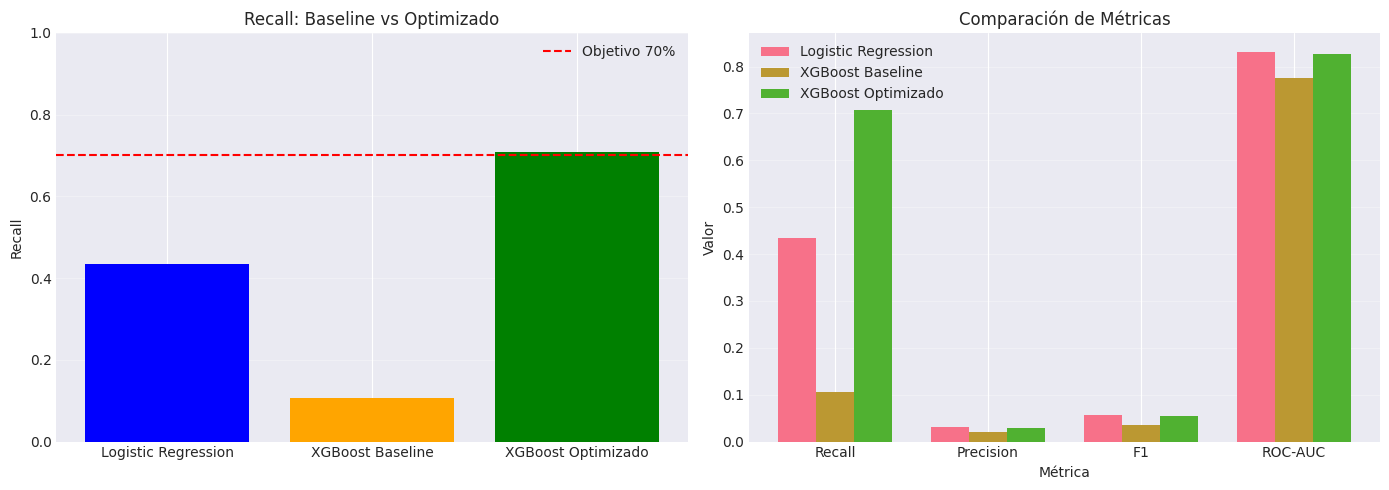


📊 Mejora Recall: +27.4 puntos porcentuales vs LR baseline
✅ Objetivo intermedio alcanzado (Recall ≥ 70%)


In [15]:
# Tabla comparativa
comparison = pd.DataFrame({
    'Modelo': ['Logistic Regression', 'XGBoost Baseline', 'XGBoost Optimizado'],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_xgb),
        recall_best
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_xgb),
        precision_best
    ],
    'F1': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_xgb),
        f1_best
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_baseline.predict_proba(X_test_processed)[:, 1]),
        roc_auc_score(y_test, xgb_baseline.predict_proba(X_test_processed)[:, 1]),
        roc_auc_best
    ]
})

# Mejora absoluta
comparison['Δ Recall'] = comparison['Recall'] - comparison.loc[0, 'Recall']

print("=== COMPARACIÓN COMPLETA ===")
print(comparison.to_string(index=False))

# Visualización
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Recall comparison
ax[0].bar(comparison['Modelo'], comparison['Recall'], color=['blue', 'orange', 'green'])
ax[0].axhline(0.70, color='red', linestyle='--', label='Objetivo 70%')
ax[0].set_ylabel('Recall')
ax[0].set_title('Recall: Baseline vs Optimizado')
ax[0].set_ylim(0, 1)
ax[0].legend()
ax[0].grid(axis='y', alpha=0.3)

# Todas las métricas
metrics_to_plot = ['Recall', 'Precision', 'F1', 'ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.25

for i, modelo in enumerate(comparison['Modelo']):
    values = [comparison.loc[i, m] for m in metrics_to_plot]
    ax[1].bar(x + i*width, values, width, label=modelo)

ax[1].set_xlabel('Métrica')
ax[1].set_ylabel('Valor')
ax[1].set_title('Comparación de Métricas')
ax[1].set_xticks(x + width)
ax[1].set_xticklabels(metrics_to_plot)
ax[1].legend()
ax[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis de mejora
mejora_recall = (recall_best - recall_score(y_test, y_pred_lr)) * 100
print(f"\n📊 Mejora Recall: {mejora_recall:+.1f} puntos porcentuales vs LR baseline")

if recall_best >= 0.85:
    print("🎉 ¡OBJETIVO ALCANZADO! Recall ≥ 85%")
elif recall_best >= 0.70:
    print("✅ Objetivo intermedio alcanzado (Recall ≥ 70%)")
else:
    print(f"⚠️ Objetivo no alcanzado. Falta {(0.70 - recall_best)*100:.1f}pp para el 70%")

## 8. FEATURE IMPORTANCE DEL MODELO OPTIMIZADO

=== TOP 15 FEATURES MÁS IMPORTANTES ===
              feature  importance
         num__fwi_p90    0.095514
         num__fwi_max    0.076412
      cat__region_nan    0.055989
             num__año    0.047842
      cat__region_Sur    0.035047
  cat__region_Levante    0.033786
          cat__mes_12    0.032824
           cat__mes_8    0.031955
 cat__region_Noroeste    0.031831
   cat__region_Centro    0.030069
cat__fwi_cat_moderado    0.026506
 cat__estacion_verano    0.025713
 cat__region_Nordeste    0.025350
          cat__mes_10    0.025347
    cat__dia_semana_1    0.025065


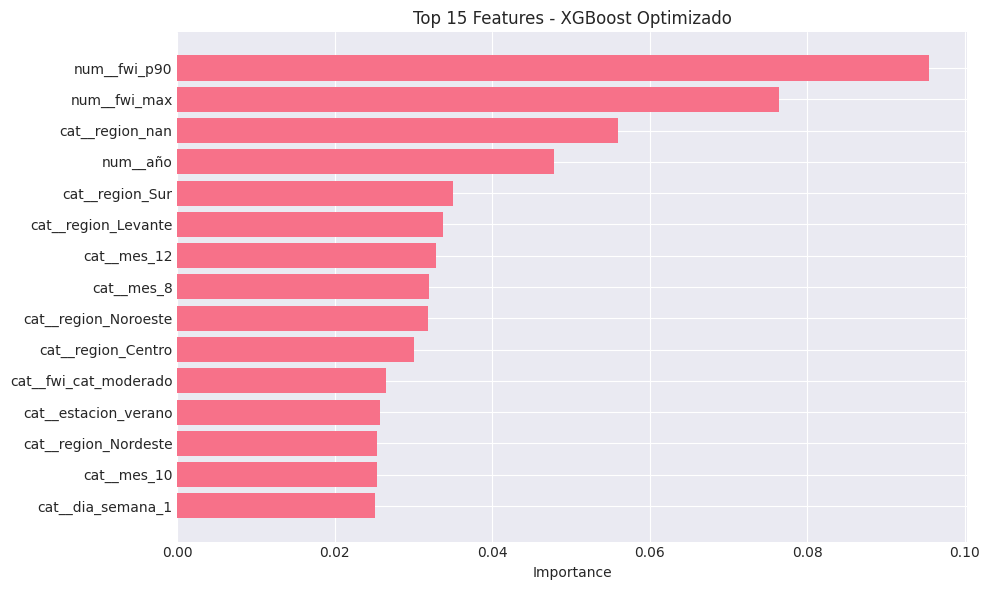

In [16]:
# Feature names
feature_names = preprocessor.get_feature_names_out()

# Importance del mejor modelo
importances = best_xgb.feature_importances_
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# Top 15 features
top_features = importance_df.head(15)

print("=== TOP 15 FEATURES MÁS IMPORTANTES ===")
print(top_features.to_string(index=False))

# Visualización
plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'][::-1], top_features['importance'][::-1])
plt.xlabel('Importance')
plt.title('Top 15 Features - XGBoost Optimizado')
plt.tight_layout()
plt.show()

## 9. CURVAS ROC Y PRECISION-RECALL

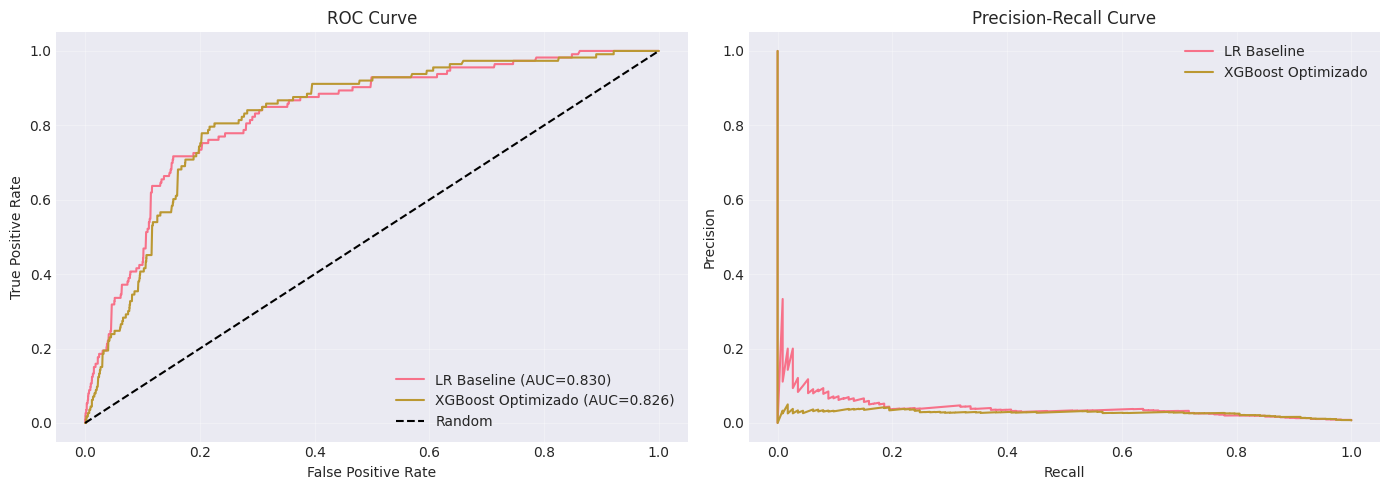

[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=6, min_child_weight=3, n_estimators=200, scale_pos_weight=125, subsample=0.8; total time=  16.6s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=8, min_child_weight=1, n_estimators=100, scale_pos_weight=75, subsample=0.8; total time=   8.6s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=8, min_child_weight=1, n_estimators=100, scale_pos_weight=125, subsample=0.8; total time=   8.2s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=8, min_child_weight=1, n_estimators=100, scale_pos_weight=200, subsample=0.8; total time=  10.7s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=8, min_child_weight=1, n_estimators=200, scale_pos_weight=100, subsample=0.8; total time=  13.9s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=8, min_child_weight=1, n_estimators=200, scale_pos_weight=150, subsample=0.8; total time=  19.4s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_baseline.predict_proba(X_test_processed)[:, 1])
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_best)

ax1.plot(fpr_lr, tpr_lr, label=f'LR Baseline (AUC={roc_auc_score(y_test, lr_baseline.predict_proba(X_test_processed)[:, 1]):.3f})')
ax1.plot(fpr_xgb, tpr_xgb, label=f'XGBoost Optimizado (AUC={roc_auc_best:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend()
ax1.grid(alpha=0.3)

# Precision-Recall Curve
precision_lr, recall_lr, _ = precision_recall_curve(y_test, lr_baseline.predict_proba(X_test_processed)[:, 1])
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_proba_best)

ax2.plot(recall_lr, precision_lr, label='LR Baseline')
ax2.plot(recall_xgb, precision_xgb, label='XGBoost Optimizado')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. ANÁLISIS DE ERRORES

=== ANÁLISIS DE ERRORES ===
Falsos Negativos (FN): 33 GIF no detectados
Probabilidad promedio FN: 0.2781
Probabilidad mediana FN: 0.2840

Falsos Positivos (FP): 2761 alertas innecesarias
Probabilidad promedio FP: 0.6890


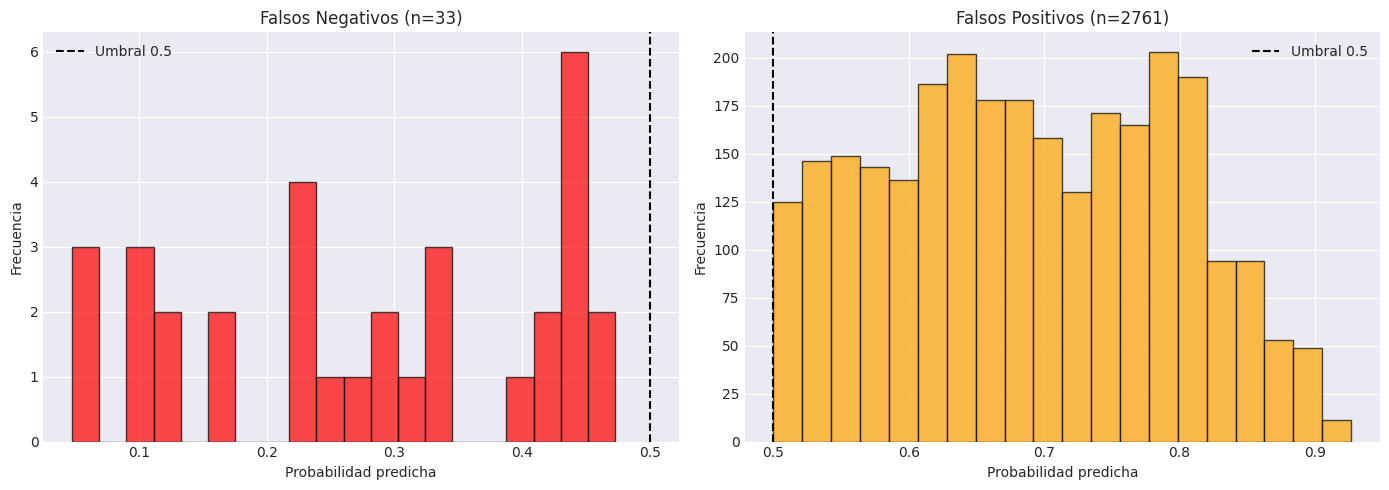

In [18]:
# Crear DataFrame con predicciones
error_analysis = pd.DataFrame({
    'y_true': y_test,
    'y_pred': y_pred_best,
    'y_proba': y_proba_best
})

# Falsos Negativos (GIF no detectados) - LO MÁS CRÍTICO
fn_mask = (error_analysis['y_true'] == 1) & (error_analysis['y_pred'] == 0)
false_negatives = error_analysis[fn_mask]

print(f"=== ANÁLISIS DE ERRORES ===")
print(f"Falsos Negativos (FN): {len(false_negatives)} GIF no detectados")
print(f"Probabilidad promedio FN: {false_negatives['y_proba'].mean():.4f}")
print(f"Probabilidad mediana FN: {false_negatives['y_proba'].median():.4f}")

# Falsos Positivos
fp_mask = (error_analysis['y_true'] == 0) & (error_analysis['y_pred'] == 1)
false_positives = error_analysis[fp_mask]
print(f"\nFalsos Positivos (FP): {len(false_positives)} alertas innecesarias")
print(f"Probabilidad promedio FP: {false_positives['y_proba'].mean():.4f}")

# Distribución de probabilidades por tipo de error
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(false_negatives['y_proba'], bins=20, alpha=0.7, color='red', edgecolor='black')
ax[0].set_xlabel('Probabilidad predicha')
ax[0].set_ylabel('Frecuencia')
ax[0].set_title(f'Falsos Negativos (n={len(false_negatives)})')
ax[0].axvline(0.5, color='black', linestyle='--', label='Umbral 0.5')
ax[0].legend()

ax[1].hist(false_positives['y_proba'], bins=20, alpha=0.7, color='orange', edgecolor='black')
ax[1].set_xlabel('Probabilidad predicha')
ax[1].set_ylabel('Frecuencia')
ax[1].set_title(f'Falsos Positivos (n={len(false_positives)})')
ax[1].axvline(0.5, color='black', linestyle='--', label='Umbral 0.5')
ax[1].legend()

plt.tight_layout()
plt.show()

## 11. GUARDAR MODELO OPTIMIZADO

In [19]:
# Guardar modelo final
timestamp = datetime.now().strftime('%Y%m%d_%H%M')
model_filename = f'../models/xgb_optimized_{timestamp}.joblib'
joblib.dump(best_xgb, model_filename)

# También guardar con nombre genérico (sobrescribe)
joblib.dump(best_xgb, '../models/xgb_optimized.joblib')

# Guardar resultados del GridSearch
results_df = pd.DataFrame(grid_search.cv_results_)
results_df.to_csv(f'../models/gridsearch_results_{timestamp}.csv', index=False)

print(f"✅ Modelo guardado en: {model_filename}")
print(f"✅ Modelo guardado en: ../models/xgb_optimized.joblib")
print(f"✅ Resultados GridSearch: ../models/gridsearch_results_{timestamp}.csv")

# Summary final
print("\n" + "="*60)
print("RESUMEN FINAL - NOTEBOOK 04: OPTIMIZACIÓN")
print("="*60)
print(f"Mejor modelo: XGBoost")
print(f"Recall:       {recall_best:.1%} ({cm[1,1]}/{cm[1,0] + cm[1,1]} GIF detectados)")
print(f"Precision:    {precision_best:.1%}")
print(f"F1-Score:     {f1_best:.4f}")
print(f"ROC-AUC:      {roc_auc_best:.4f}")
print(f"\nMejora vs LR Baseline: {mejora_recall:+.1f}pp de Recall")
print(f"Tiempo ejecución: {datetime.now()}")
print("="*60)

✅ Modelo guardado en: ../models/xgb_optimized_20260208_2109.joblib
✅ Modelo guardado en: ../models/xgb_optimized.joblib
✅ Resultados GridSearch: ../models/gridsearch_results_20260208_2109.csv

RESUMEN FINAL - NOTEBOOK 04: OPTIMIZACIÓN
Mejor modelo: XGBoost
Recall:       70.8% (80/113 GIF detectados)
Precision:    2.8%
F1-Score:     0.0542
ROC-AUC:      0.8258

Mejora vs LR Baseline: +27.4pp de Recall
Tiempo ejecución: 2026-02-08 21:09:01.453003
